In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

label_names = list(train_dataset.info['label'].values())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Data chargée  | Device : {device}")

Data chargée  | Device : cpu


In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


class ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, 
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=14):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = (img_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embed

        x = self.transformer(x)
        x = self.norm(x[:, 0])  # CLS token
        x = self.head(x)
        return x


model = ViT().to(device)
print("ViT chargé ")

ViT chargé 


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

torch.manual_seed(42)
np.random.seed(42)

print("Setup ok")

Setup ok


In [7]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=3):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # ── Validation ──
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.float().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=3)

Epoch [1/3] | Train Loss: 0.1837 | Val Loss: 0.1815
Epoch [2/3] | Train Loss: 0.1833 | Val Loss: 0.1809
Epoch [3/3] | Train Loss: 0.1832 | Val Loss: 0.1811


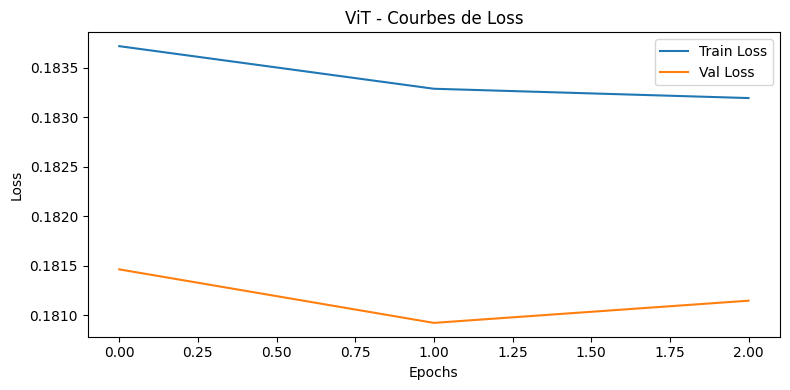

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT - Courbes de Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_preds_binary = (all_preds >= 0.5).astype(int)

aucs = []
print("=" * 45)
print(f"{'Pathologie':<20} | {'AUC':>6} | {'F1':>6}")
print("=" * 45)
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    f1 = f1_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    aucs.append(auc)
    print(f"{name:<20} | {auc:>6.4f} | {f1:>6.4f}")

print("=" * 45)
print(f"{'Moyenne':<20} | {np.mean(aucs):>6.4f} | {f1_score(all_labels, all_preds_binary, average='macro', zero_division=0):>6.4f}")

torch.save(model.state_dict(), 'vit.pth')
print("\nModèle sauvegardé ")

Pathologie           |    AUC |     F1
atelectasis          | 0.4523 | 0.0000
cardiomegaly         | 0.4425 | 0.0000
effusion             | 0.4387 | 0.0000
infiltration         | 0.4926 | 0.0000
mass                 | 0.5062 | 0.0000
nodule               | 0.5481 | 0.0000
pneumonia            | 0.5663 | 0.0000
pneumothorax         | 0.4481 | 0.0000
consolidation        | 0.4802 | 0.0000
edema                | 0.3371 | 0.0000
emphysema            | 0.4783 | 0.0000
fibrosis             | 0.5784 | 0.0000
pleural              | 0.5250 | 0.0000
hernia               | 0.6000 | 0.0000
Moyenne              | 0.4924 | 0.0000

Modèle sauvegardé 
